# RetailRocket Recommendation Dataset Audit

**Phase 0D — descriptive audit only.** This notebook preserves chronology and distinguishes views, cart additions, and transactions. It creates no recommender, target, embedding, event weight, or random split. `visitorid` is an anonymous observed identifier, not a verified registered customer.

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option('display.max_columns',100)
RAW=Path('../data/raw/retailrocket')
FILES=sorted(RAW.glob('*.csv'))
assert [p.name for p in FILES]==['category_tree.csv','events.csv','item_properties_part1.csv','item_properties_part2.csv']
[(p.name,p.stat().st_size/1024**2) for p in FILES]

[('category_tree.csv', 0.013784408569335938),
 ('events.csv', 89.87227725982666),
 ('item_properties_part1.csv', 461.87949085235596),
 ('item_properties_part2.csv', 389.9859495162964)]

## 1. File-level integrity and grain
Each canonical CSV is loaded independently. Exact duplicate counts are calculated per file. The two property files are storage partitions of one logical change-log table, not different schemas.

In [2]:
dtypes={'events.csv':{'timestamp':'int64','visitorid':'int64','event':'category','itemid':'int64','transactionid':'float64'},'category_tree.csv':{'categoryid':'int64','parentid':'float64'},'item_properties_part1.csv':{'timestamp':'int64','itemid':'int64','property':'string','value':'string'},'item_properties_part2.csv':{'timestamp':'int64','itemid':'int64','property':'string','value':'string'}}
keys={'events.csv':['timestamp','visitorid','event','itemid','transactionid'],'category_tree.csv':['categoryid'],'item_properties_part1.csv':['timestamp','itemid','property'],'item_properties_part2.csv':['timestamp','itemid','property']}
summaries=[]; missing={}
for p in FILES:
    df=pd.read_csv(p,dtype=dtypes[p.name]); k=keys[p.name]
    summaries.append({'file':p.name,'rows':len(df),'columns':df.shape[1],'disk_mb':p.stat().st_size/1024**2,'memory_mb':df.memory_usage(deep=True).sum()/1024**2,'duplicate_rows':int(df.duplicated().sum()),'candidate_key':' + '.join(k),'key_duplicate_rows':int(df.duplicated(k,keep=False).sum())})
    missing[p.name]=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing_n':df.isna().sum(),'missing_pct':df.isna().mean()*100})
    del df; gc.collect()
display(pd.DataFrame(summaries).round(3))
for name,x in missing.items(): print('\n'+name); display(x.round(3))
grain=pd.DataFrame([['events.csv','one visitor-item event at a timestamp','no guaranteed unique event ID','visitorid, itemid, transactionid'],['category_tree.csv','one category node and optional parent','categoryid','parentid'],['item_properties parts','one timestamped item-property value/change-log row','timestamp + itemid + property (to validate)','itemid']],columns=['table','row_grain','candidate_key','important_identifiers']); display(grain)

,file,rows,columns,disk_mb,memory_mb,duplicate_rows,candidate_key,key_duplicate_rows
0,category_tree.csv,1669,2,0.014,0.026,0,categoryid,0
1,events.csv,2756101,5,89.872,86.738,460,timestamp + visitorid + event + itemid + trans...,918
2,item_properties_part1.csv,10999999,4,461.879,1419.011,0,timestamp + itemid + property,0
3,item_properties_part2.csv,9275903,4,389.986,1197.099,0,timestamp + itemid + property,0



category_tree.csv


,dtype,missing_n,missing_pct
categoryid,int64,0,0.000
parentid,float64,25,1.498



events.csv


,dtype,missing_n,missing_pct
timestamp,int64,0,0.000
visitorid,int64,0,0.000
event,category,0,0.000
itemid,int64,0,0.000
transactionid,float64,2733644,99.185



item_properties_part1.csv


,dtype,missing_n,missing_pct
timestamp,int64,0,0.0
itemid,int64,0,0.0
property,string,0,0.0
value,string,0,0.0



item_properties_part2.csv


,dtype,missing_n,missing_pct
timestamp,int64,0,0.0
itemid,int64,0,0.0
property,string,0,0.0
value,string,0,0.0


,table,row_grain,candidate_key,important_identifiers
0,events.csv,one visitor-item event at a timestamp,no guaranteed unique event ID,"visitorid, itemid, transactionid"
1,category_tree.csv,one category node and optional parent,categoryid,parentid
2,item_properties parts,one timestamped item-property value/change-log...,timestamp + itemid + property (to validate),itemid


## 2. Event and temporal audit
Epoch milliseconds are converted to UTC. Daily/weekly counts expose boundaries and gaps. Missing transaction IDs are expected for non-transaction events and are evaluated by event type.

In [3]:
events=pd.read_csv(RAW/'events.csv',dtype=dtypes['events.csv']); events['event_time']=pd.to_datetime(events.timestamp,unit='ms',utc=True); events['day']=events.event_time.dt.floor('D')
event_counts=events.event.value_counts(); event_pct=events.event.value_counts(normalize=True).mul(100); display(pd.concat([event_counts.rename('events'),event_pct.rename('pct')],axis=1))
temporal=pd.Series({'events':len(events),'visitors':events.visitorid.nunique(),'items':events.itemid.nunique(),'earliest':events.event_time.min(),'latest':events.event_time.max(),'duration_days':(events.event_time.max()-events.event_time.min()).total_seconds()/86400,'active_days':events.day.nunique(),'missing_event_fields_excluding_transactionid':events[['timestamp','visitorid','event','itemid']].isna().sum().sum(),'transactionid_present':events.transactionid.notna().sum()}); display(temporal.to_frame('value'))
daily=events.groupby(['day','event'],observed=True).size().unstack(fill_value=0); weekly=events.set_index('event_time').groupby('event',observed=True).resample('W').size().unstack(0,fill_value=0); display(daily.head(),daily.tail(),weekly)
all_days=pd.date_range(events.day.min(),events.day.max(),freq='D',tz='UTC'); print('Zero-event calendar days:',len(all_days.difference(pd.DatetimeIndex(events.day.unique())))); print('Boundary-day counts:',daily.iloc[[0,-1]])

,events,pct
event,,
view,2664312,96.669607
addtocart,69332,2.515583
transaction,22457,0.814810


,value
events,2756101
visitors,1407580
items,235061
earliest,2015-05-03 03:00:04.384000+00:00
latest,2015-09-18 02:59:47.788000+00:00
duration_days,137.999808
active_days,139
missing_event_fields_excluding_transactionid,0
transactionid_present,22457


event,addtocart,transaction,view
day,,,
2015-05-03 00:00:00+00:00,296,83,13304
2015-05-04 00:00:00+00:00,579,154,18681
2015-05-05 00:00:00+00:00,565,225,22225
2015-05-06 00:00:00+00:00,647,258,23015
2015-05-07 00:00:00+00:00,578,217,22369


event,addtocart,transaction,view
day,,,
2015-09-14 00:00:00+00:00,475,154,20284
2015-09-15 00:00:00+00:00,595,158,19674
2015-09-16 00:00:00+00:00,336,137,11022
2015-09-17 00:00:00+00:00,253,45,9830
2015-09-18 00:00:00+00:00,34,15,1479


event,addtocart,transaction,view
event_time,,,
2015-05-03 00:00:00+00:00,296,83,13304
2015-05-10 00:00:00+00:00,3492,1103,129180
2015-05-17 00:00:00+00:00,3642,1218,144001
2015-05-24 00:00:00+00:00,3419,1061,148034
2015-05-31 00:00:00+00:00,3520,1146,137153
2015-06-07 00:00:00+00:00,3405,1174,141866
2015-06-14 00:00:00+00:00,3081,966,127805
2015-06-21 00:00:00+00:00,4036,1316,140624
2015-06-28 00:00:00+00:00,3520,1222,136946


Zero-event calendar days: 0
Boundary-day counts: event                      addtocart  transaction   view
day                                                     
2015-05-03 00:00:00+00:00        296           83  13304
2015-09-18 00:00:00+00:00         34           15   1479


## 3. Visitor identity depth
Activity depth does not establish that visitor IDs are authenticated, durable across devices, or stable after cookie clearing. No explicit session ID exists, so this audit reports repeat active days rather than imposing an arbitrary session timeout.

In [4]:
v=events.groupby('visitorid').agg(events=('event','size'),first=('event_time','min'),last=('event_time','max'),active_days=('day','nunique')); v['active_span_days']=(v['last']-v['first']).dt.total_seconds()/86400
visitor_stats=pd.Series({'visitors':len(v),'median events':v.events.median(),'mean events':v.events.mean(),'75th percentile':v.events.quantile(.75),'90th percentile':v.events.quantile(.9),'maximum':v.events.max(),'exactly 1 event pct':v.events.eq(1).mean()*100,'at least 2 pct':v.events.ge(2).mean()*100,'at least 5 pct':v.events.ge(5).mean()*100,'at least 10 pct':v.events.ge(10).mean()*100,'multiple active days pct':v.active_days.ge(2).mean()*100}); display(visitor_stats.to_frame('value'))
display(v[['active_span_days','active_days']].describe(percentiles=[.5,.75,.9,.95,.99]).T)

,value
visitors,1.407580e+06
median events,1.000000e+00
mean events,1.958042e+00
75th percentile,2.000000e+00
90th percentile,3.000000e+00
maximum,7.757000e+03
exactly 1 event pct,7.115475e+01
at least 2 pct,2.884525e+01
at least 5 pct,5.798605e+00
at least 10 pct,1.651132e+00


,count,mean,std,min,50%,75%,90%,95%,99%,max
active_span_days,1407580.0,2.375490,11.630812,0.0,0.0,0.000544,0.480409,10.309823,69.089319,137.972858
active_days,1407580.0,1.171894,0.928101,1.0,1.0,1.000000,2.000000,2.000000,4.000000,131.000000


## 4. Item interaction depth and long tail
Long-tail items remain in the audit. Concentration is descriptive and is not a removal rule.

,value
items,235061.000000
median events/item,3.000000
mean events/item,11.725046
median visitors/item,2.000000
items with 1 event pct,31.314850
items with <=5 events pct,65.839505
top 1% item event share pct,22.954638
top 10 items event share pct,0.745111
maximum item events,3412.000000


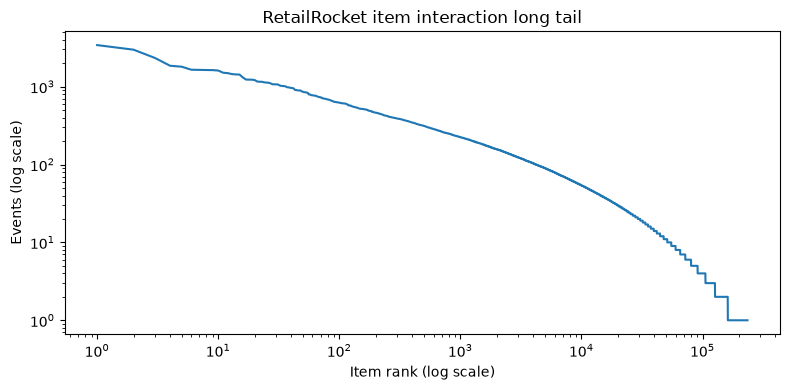

Interpretation: activity is highly concentrated while many items have little collaborative evidence.


In [5]:
item=events.groupby('itemid').agg(events=('event','size'),visitors=('visitorid','nunique')).sort_values('events',ascending=False); n_top=max(1,int(np.ceil(len(item)*.01)))
item_stats=pd.Series({'items':len(item),'median events/item':item.events.median(),'mean events/item':item.events.mean(),'median visitors/item':item.visitors.median(),'items with 1 event pct':item.events.eq(1).mean()*100,'items with <=5 events pct':item.events.le(5).mean()*100,'top 1% item event share pct':item.head(n_top).events.sum()/item.events.sum()*100,'top 10 items event share pct':item.head(10).events.sum()/item.events.sum()*100,'maximum item events':item.events.max()}); display(item_stats.to_frame('value'))
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(np.arange(1,len(item)+1),item.events.to_numpy()); ax.set(xscale='log',yscale='log',title='RetailRocket item interaction long tail',xlabel='Item rank (log scale)',ylabel='Events (log scale)'); plt.tight_layout(); plt.show(); print('Interpretation: activity is highly concentrated while many items have little collaborative evidence.')

## 5. User-item matrices
Distinct pairs are reported for all event types and transactions alone. Views, carts, and purchases are not assigned weights or treated as equivalent.

In [6]:
def matrix_stats(df,label):
    pairs=df[['visitorid','itemid']].drop_duplicates(); users=pairs.visitorid.nunique(); items_n=pairs.itemid.nunique(); pu=pairs.groupby('visitorid').size(); pi=pairs.groupby('itemid').size(); possible=int(users)*int(items_n)
    return pd.Series({'scope':label,'visitors':users,'items':items_n,'distinct_pairs':len(pairs),'sparsity_pct':(1-len(pairs)/possible)*100,'mean_pairs_per_visitor':pu.mean(),'median_pairs_per_visitor':pu.median(),'mean_pairs_per_item':pi.mean(),'median_pairs_per_item':pi.median()})
all_matrix=matrix_stats(events,'all events'); tx=events[events.event=='transaction'].copy(); tx_matrix=matrix_stats(tx,'transactions only'); display(pd.DataFrame([all_matrix,tx_matrix]).set_index('scope'))

,visitors,items,distinct_pairs,sparsity_pct,mean_pairs_per_visitor,median_pairs_per_visitor,mean_pairs_per_item,median_pairs_per_item
scope,,,,,,,,
all events,1407580,235061,2145179,99.999352,1.524019,1.0,9.126052,2.0
transactions only,11719,12025,21270,99.984906,1.815001,1.0,1.768815,1.0


## 6. Temporally ordered funnel
For each visitor-item pair, transition counts require the later event timestamp to follow the earlier event. These are observed sequences, not causal conversion effects.

In [7]:
funnel_entities=pd.DataFrame({'visitors':events.groupby('event',observed=True).visitorid.nunique(),'items':events.groupby('event',observed=True).itemid.nunique(),'events':event_counts}); display(funnel_entities)
bounds=events.groupby(['visitorid','itemid','event'],observed=True).event_time.agg(['min','max']).unstack('event')
funnel=pd.Series({'visitor-item pairs':len(bounds),'view then later cart':((bounds[('min','view')].notna())&(bounds[('max','addtocart')].notna())&(bounds[('max','addtocart')]>=bounds[('min','view')])).sum(),'cart then later transaction':((bounds[('min','addtocart')].notna())&(bounds[('max','transaction')].notna())&(bounds[('max','transaction')]>=bounds[('min','addtocart')])).sum(),'view then later transaction':((bounds[('min','view')].notna())&(bounds[('max','transaction')].notna())&(bounds[('max','transaction')]>=bounds[('min','view')])).sum()}); display(funnel.to_frame('pairs'))

,visitors,items,events
event,,,
addtocart,37722,23903,69332
transaction,11719,12025,22457
view,1404179,234838,2664312


,pairs
visitor-item pairs,2145179
view then later cart,45810
cart then later transaction,19003
view then later transaction,18778


## 7. Transaction behavior
Purchase analysis uses transaction events only. Transaction-only recommendation evidence is compared with the richer event stream; it is not used for churn.

In [8]:
buyers=tx.groupby('visitorid').agg(transaction_events=('event','size'),purchased_items=('itemid','nunique'),transaction_ids=('transactionid','nunique'),first_purchase=('event_time','min'),last_purchase=('event_time','max')); buyers['purchase_span_days']=(buyers.last_purchase-buyers.first_purchase).dt.total_seconds()/86400
ordered_tx=tx.sort_values(['visitorid','event_time']); purchase_intervals=ordered_tx.groupby('visitorid').event_time.diff().dt.total_seconds().div(86400).dropna()
transaction_stats=pd.Series({'purchasing visitors':len(buyers),'median transaction events':buyers.transaction_events.median(),'mean transaction events':buyers.transaction_events.mean(),'buyers with >=2 transaction events pct':buyers.transaction_events.ge(2).mean()*100,'median distinct purchased items':buyers.purchased_items.median(),'buyers with >=2 purchased items pct':buyers.purchased_items.ge(2).mean()*100,'median purchase span days':buyers.purchase_span_days.median(),'buyers spanning >0 days pct':buyers.purchase_span_days.gt(0).mean()*100,'repeated visitor-item purchase events':len(tx)-len(tx[['visitorid','itemid']].drop_duplicates())}); display(transaction_stats.to_frame('value')); display(purchase_intervals.describe(percentiles=[.25,.5,.75,.9,.95,.99]).to_frame('days'))

,value
purchasing visitors,11719.000000
median transaction events,1.000000
mean transaction events,1.916290
buyers with >=2 transaction events pct,21.981398
median distinct purchased items,1.000000
buyers with >=2 purchased items pct,18.551071
median purchase span days,0.000000
buyers spanning >0 days pct,17.979350
repeated visitor-item purchase events,1187.000000


,days
count,1.073800e+04
mean,1.168611e+00
std,6.462946e+00
min,0.000000e+00
25%,1.851852e-07
50%,5.711279e-03
75%,4.571137e-02
90%,7.959550e-01
95%,3.902040e+00
99%,3.255616e+01


## 8. Temporal evaluation feasibility and cold start
Three fixed descriptive cutoffs (60%, 75%, and 90% through elapsed time) probe feasibility; none is selected or optimized. Eligibility requires history before T and at least one interaction after T. Cold-start users/items are measured, not removed.

In [9]:
start,end=events.event_time.min(),events.event_time.max(); rows=[]
for frac in [.60,.75,.90]:
    cutoff=start+(end-start)*frac; hist=events[events.event_time<cutoff]; future=events[events.event_time>=cutoff]; hc=hist.groupby('visitorid').size(); future_users=set(future.visitorid.unique()); hist_users=set(hist.visitorid.unique()); hist_items=set(hist.itemid.unique()); unseen_user=~future.visitorid.isin(hist_users); unseen_item=~future.itemid.isin(hist_items)
    row={'cutoff_fraction':frac,'cutoff':cutoff,'history_events':len(hist),'future_events':len(future),'future_visitors':future.visitorid.nunique(),'future_items':future.itemid.nunique(),'future visitors unseen pct':len(future_users-hist_users)/len(future_users)*100,'future items unseen pct':len(set(future.itemid.unique())-hist_items)/future.itemid.nunique()*100,'future events unseen visitor pct':unseen_user.mean()*100,'future events unseen item pct':unseen_item.mean()*100}
    for n in [2,5,10]: row[f'eligible hist>={n} + future']=sum((hc>=n)&hc.index.isin(future_users))
    rows.append(row)
cutoffs=pd.DataFrame(rows); display(cutoffs)
print('Interpretation: collaborative evaluation applies only to warm users/items; cold-start events need separately reported popularity/metadata fallbacks, not silent exclusion.')

,cutoff_fraction,cutoff,history_events,future_events,future_visitors,future_items,future visitors unseen pct,future items unseen pct,future events unseen visitor pct,future events unseen item pct,eligible hist>=2 + future,eligible hist>=5 + future,eligible hist>=10 + future
0,0.60,2015-07-24 22:11:54.426000+00:00,1723427,1032674,564190,154539,94.278523,27.565857,88.980453,9.839117,15808,5567,2425
1,0.75,2015-08-14 14:59:51.937000+00:00,2141303,614798,343111,120831,92.414117,20.579156,86.405291,7.604612,13378,4944,2203
2,0.90,2015-09-04 07:47:49.447000+00:00,2512418,243683,140140,71858,89.560440,13.203819,82.815379,5.923269,7921,3226,1530


Interpretation: collaborative evaluation applies only to warm users/items; cold-start events need separately reported popularity/metadata fallbacks, not silent exclusion.


## 9. Item metadata audit
Item properties are timestamped change-log records. The two large parts are processed in chunks to measure combined coverage without retaining a multi-gigabyte frame. Values other than category/availability are hashed and are not assumed to have business meaning.

In [10]:
prop_counts={}; prop_items={}; metadata_items=set(); category_items=set(); available_items=set(); timestamps=[]; total_prop_rows=0
for name in ['item_properties_part1.csv','item_properties_part2.csv']:
    for chunk in pd.read_csv(RAW/name,dtype=dtypes[name],chunksize=500_000):
        total_prop_rows+=len(chunk); metadata_items.update(chunk.itemid.unique().tolist()); timestamps.extend([chunk.timestamp.min(),chunk.timestamp.max()]); counts=chunk.property.value_counts()
        for k,val in counts.items(): prop_counts[k]=prop_counts.get(k,0)+int(val)
        category_items.update(chunk.loc[chunk.property=='categoryid','itemid'].unique().tolist()); available_items.update(chunk.loc[chunk.property=='available','itemid'].unique().tolist())
metadata=pd.Series({'property rows':total_prop_rows,'items with any properties':len(metadata_items),'items in events with any property pct':events.itemid.isin(metadata_items).groupby(events.itemid).first().mean()*100,'items with category property':len(category_items),'event items with category coverage pct':events.itemid.isin(category_items).groupby(events.itemid).first().mean()*100,'items with availability property':len(available_items),'event items with availability coverage pct':events.itemid.isin(available_items).groupby(events.itemid).first().mean()*100,'property earliest UTC':pd.to_datetime(min(timestamps),unit='ms',utc=True),'property latest UTC':pd.to_datetime(max(timestamps),unit='ms',utc=True),'distinct property labels':len(prop_counts)}); display(metadata.to_frame('value')); display(pd.Series(prop_counts).sort_values(ascending=False).head(15).to_frame('rows'))
tree=pd.read_csv(RAW/'category_tree.csv',dtype=dtypes['category_tree.csv']); display(pd.Series({'category nodes':len(tree),'unique category ids':tree.categoryid.nunique(),'root categories (missing parent)':tree.parentid.isna().sum(),'parent ids absent as nodes':(~tree.parentid.dropna().astype(int).isin(tree.categoryid)).sum()}).to_frame('value'))

,value
property rows,20275902
items with any properties,417053
items in events with any property pct,78.807629
items with category property,417053
event items with category coverage pct,78.807629
items with availability property,417053
event items with availability coverage pct,78.807629
property earliest UTC,2015-05-10 03:00:00+00:00
property latest UTC,2015-09-13 03:00:00+00:00
distinct property labels,1104


,rows
888,3000398
790,1790516
available,1503639
categoryid,788214
6,631471
283,597419
776,574220
678,481966
364,476486
202,448938


,value
category nodes,1669
unique category ids,1669
root categories (missing parent),25
parent ids absent as nodes,0


## 10. Computational feasibility
The event table fits comfortably in local Pandas. The property change log is the main cost and should be chunked or filtered by relevant items/properties/times before feature work; distributed systems are not assumed.

In [11]:
resources=pd.DataFrame(summaries).sort_values('memory_mb',ascending=False); display(resources[['file','disk_mb','rows','memory_mb']].round(2)); print('Total raw disk MB:',resources.disk_mb.sum()); print('Estimated deep memory if all full files retained MB:',resources.memory_mb.sum()); print('Events processing is practical locally; full metadata should be scanned sequentially/chunked to avoid retaining both parts.')

,file,disk_mb,rows,memory_mb
2,item_properties_part1.csv,461.88,10999999,1419.01
3,item_properties_part2.csv,389.99,9275903,1197.10
1,events.csv,89.87,2756101,86.74
0,category_tree.csv,0.01,1669,0.03


Total raw disk MB: 941.7515020370483
Estimated deep memory if all full files retained MB: 2702.873589515686
Events processing is practical locally; full metadata should be scanned sequentially/chunked to avoid retaining both parts.


## Methodological conclusion

RetailRocket provides real e-commerce implicit feedback and sufficient chronology to investigate temporal ranking protocols. Its anonymous visitor identity, short 4.5-month window, extreme sparsity, and cold-start population are first-class evaluation conditions—not records to remove for prettier metrics. Future work must report views, carts, and purchases separately, preserve time, compare against popularity/fallback baselines, and never describe recommendation scores as probabilities.